In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("4.X_scaled.csv")
df.head()

C:\Users\kumar_santhosh\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\kumar_santhosh\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


,Income,Age,Customer_Days,Recency,Total_Spending,Total_Purchases,Total_Children
0,0.288513,1.016868,1.529793,0.306856,1.680176,1.319340,-1.264308
1,-0.262438,1.273264,-1.191143,-0.383971,-0.962202,-1.155857,1.395139
2,0.917992,0.333146,-0.206659,-0.798467,0.282541,0.798246,-1.264308
3,-1.182621,-1.290693,-1.062517,-0.798467,-0.918994,-0.895310,0.065416
4,0.295754,-1.034298,-0.953679,1.550344,-0.305762,0.537699,0.065416


In [2]:
from sklearn.cluster import KMeans

In [3]:
X_scaled = df[['Income', 'Recency', 'Customer_Days', 'Total_Spending', 'Total_Purchases']]

In [4]:
X_scaled_df = pd.DataFrame(X_scaled, columns = ['Income', 'Recency', 'Customer_Days', 'Total_Spending', 'Total_Purchases'])
X_scaled_df.head()

,Income,Recency,Customer_Days,Total_Spending,Total_Purchases
0,0.288513,0.306856,1.529793,1.680176,1.319340
1,-0.262438,-0.383971,-1.191143,-0.962202,-1.155857
2,0.917992,-0.798467,-0.206659,0.282541,0.798246
3,-1.182621,-0.798467,-1.062517,-0.918994,-0.895310
4,0.295754,1.550344,-0.953679,-0.305762,0.537699


In [5]:
from sklearn.metrics import silhouette_score

sil_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled_df)
    score = silhouette_score(X_scaled_df, labels)
    sil_scores.append(score)
    print(f"K={k}, Silhouette Score={score}")

K=2, Silhouette Score=0.34965656346934454
K=3, Silhouette Score=0.25868251135580766
K=4, Silhouette Score=0.2295113824125816
K=5, Silhouette Score=0.22612199746696027
K=6, Silhouette Score=0.2250653304741234
K=7, Silhouette Score=0.23629571639138
K=8, Silhouette Score=0.23462775945765899
K=9, Silhouette Score=0.23599946935585983
K=10, Silhouette Score=0.23741663882748806


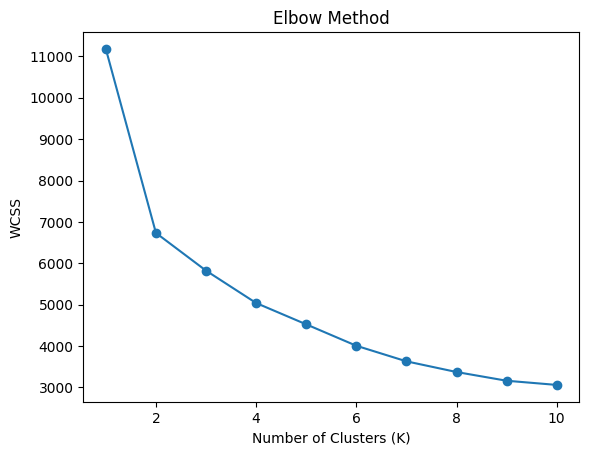

In [6]:
#Elobow Method
import matplotlib.pyplot as plt
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled_df)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

In [7]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled_df)
X_scaled = X_scaled_df.values
X_scaled_df['Cluster'] = clusters

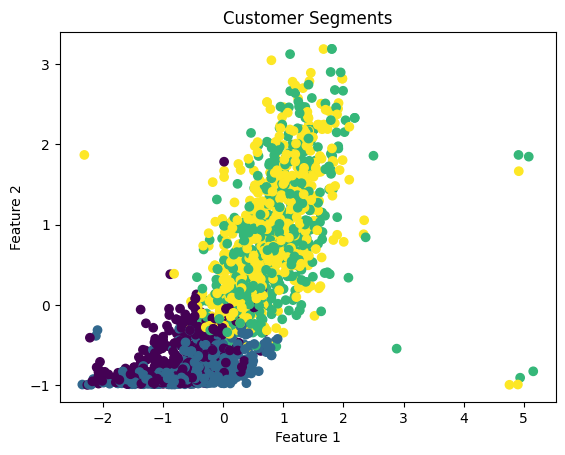

In [8]:
plt.scatter(X_scaled_df['Income'], X_scaled_df['Total_Spending'], c=clusters, cmap='viridis')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Customer Segments')
plt.show()

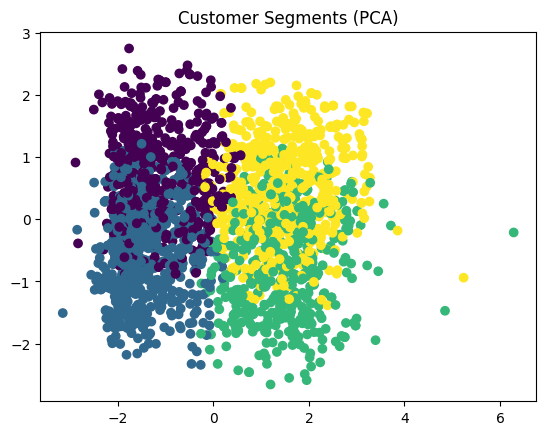

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_df.drop('Cluster', axis=1))

plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis')
plt.title("Customer Segments (PCA)")
plt.show()

In [10]:
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")
X_scaled_df.to_csv("clustered_data.csv", index=False)

In [14]:
df['Cluster'] = kmeans.labels_
df.head()

,Income,Age,Customer_Days,Recency,Total_Spending,Total_Purchases,Total_Children,Cluster
0,0.288513,1.016868,1.529793,0.306856,1.680176,1.319340,-1.264308,3
1,-0.262438,1.273264,-1.191143,-0.383971,-0.962202,-1.155857,1.395139,1
2,0.917992,0.333146,-0.206659,-0.798467,0.282541,0.798246,-1.264308,2
3,-1.182621,-1.290693,-1.062517,-0.798467,-0.918994,-0.895310,0.065416,1
4,0.295754,-1.034298,-0.953679,1.550344,-0.305762,0.537699,0.065416,3


In [17]:
cluster_profile = df.groupby('Cluster').mean(numeric_only=True)
print(cluster_profile)

           Income       Age  Customer_Days   Recency  Total_Spending  \
Cluster                                                                
0       -0.842145 -0.184691       0.849815 -0.127906       -0.720299   
1       -0.649036 -0.129294      -0.881351  0.061692       -0.826825   
2        0.886499  0.147134      -0.089352 -0.888920        0.877626   
3        0.787818  0.199568       0.273242  0.841315        0.883156   

         Total_Purchases  Total_Children  
Cluster                                   
0              -0.634282        0.264138  
1              -0.868245        0.420009  
2               0.871442       -0.420082  
3               0.852839       -0.372245  


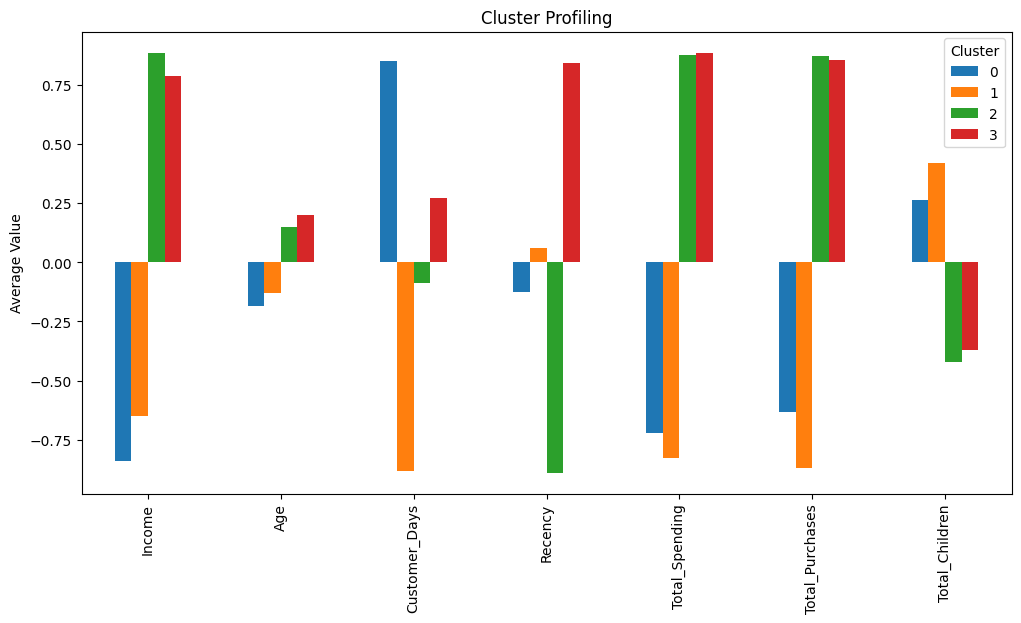

In [18]:
cluster_profile.T.plot(kind='bar', figsize=(12,6))
plt.title("Cluster Profiling")
plt.ylabel("Average Value")
plt.show()